In [1]:
begin
    using Pkg
    dev_folder = joinpath(@__DIR__, "..")
    Pkg.activate(dev_folder)
end
Threads.nthreads()

  Activating project at `~/Realizibility_index/BindingAndCatalysis.jl/Examples`


24

In [2]:
using Polyhedra
using GLMakie # for plotting, we use Makie backend, could also be GLMakie or WGLMakie...
using Revise
using BindingAndCatalysis # import the package

[ Info: Precompiling BindingAndCatalysis [b532a4b1-2c45-4c12-bcaf-8695372aa40c] (cache misses: include_dependency fsize change (2), incompatible header (4))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :

In [3]:
        #Gene   R1     R2   G-R1 G-R2
# x_sym = [:G,    :R₁,   :R₂ , :C₁ , :C₂]
x_sym = [:E,    :S,   :P , :Cs , :Cp]
N =     [1      1     0      -1    0
         1      0     1        0    -1]

# q_sym = [:Gt, :R1t, :R2t]
q_sym = [:tE, :tS, :tP]
K_sym = [:K₁, :K₂]
model = Bnc(N=N,x_sym=x_sym,q_sym=q_sym,K_sym=K_sym)

----------Binding Network Summary:-------------
Number of species (n): 5
Number of conserved quantities (d): 3
Number of reactions (r): 2
L matrix: [1 0 … 1 1; 0 1 … 1 0; 0 0 … 0 1]
N matrix: [1 1 … -1 0; 1 0 … 0 -1]
Direction of binding reactions: forward
Catalysis involved: No
Regimes constructed: No
-----------------------------------------------

[ Info: ---------------------Start finding all vertices--------------------
[ Info: Finished, with 12 vertices found and 12 asymptotic vertices.
[ Info: -------------Start calculating nullity for each vertex, it also takes a while.------------
[ Info: 1.Building Nρ_inv cache in parallel...
Progress: 100%|█████████████████████████████████████████| Time: 0:00:00
[ Info: 2.Calculating nullity for each vertex in parallel...
[ Info: Start calculating vertices neighbor graph, It may takes a while.
Progress: 100%|█████████████████████████████████████████| Time: 0:00:00
[ Info: Calculating vertices neighbor graph with qK change dir
Progress: 100%|█████████████████████████████████████████| Time: 0:00:00
[ Info: Number of polyhedra to calc volume: 8
[ Info: All regimes converged after 6500000 samples.


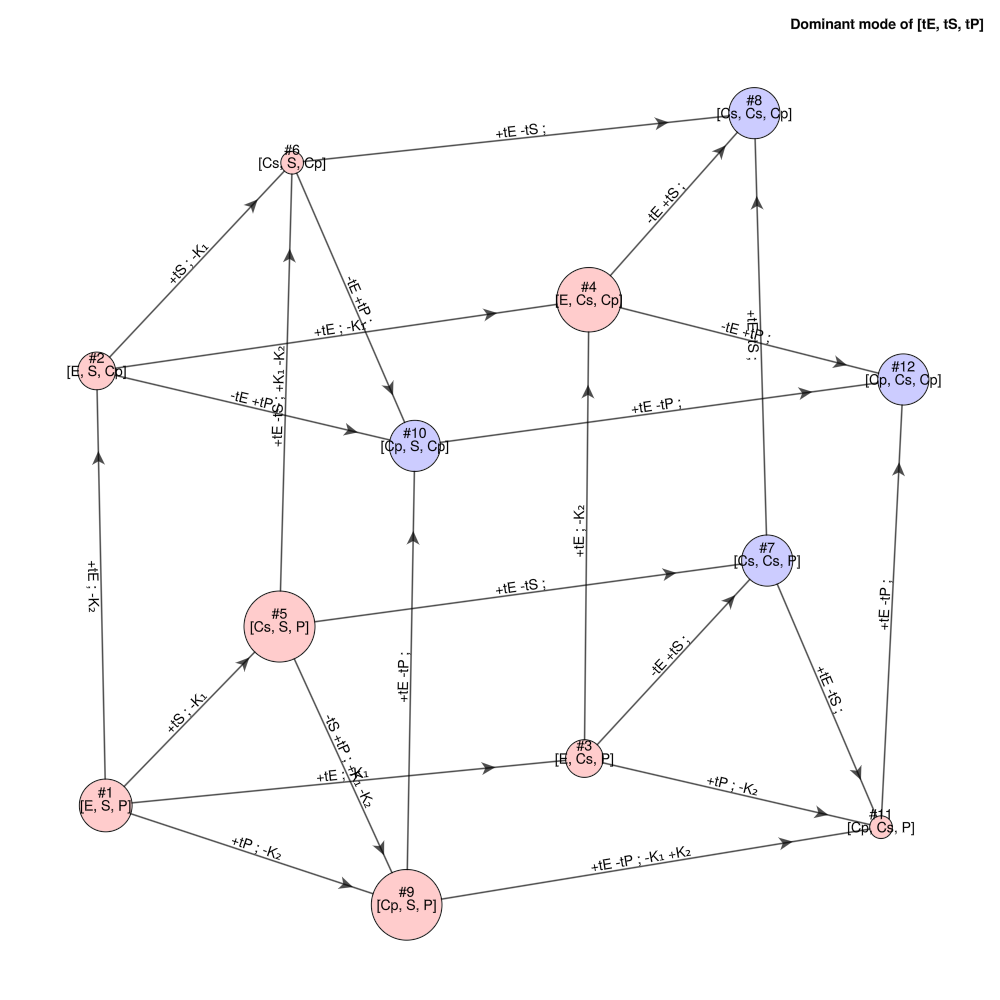

In [4]:
f,ax,p = draw_graph(model)
f

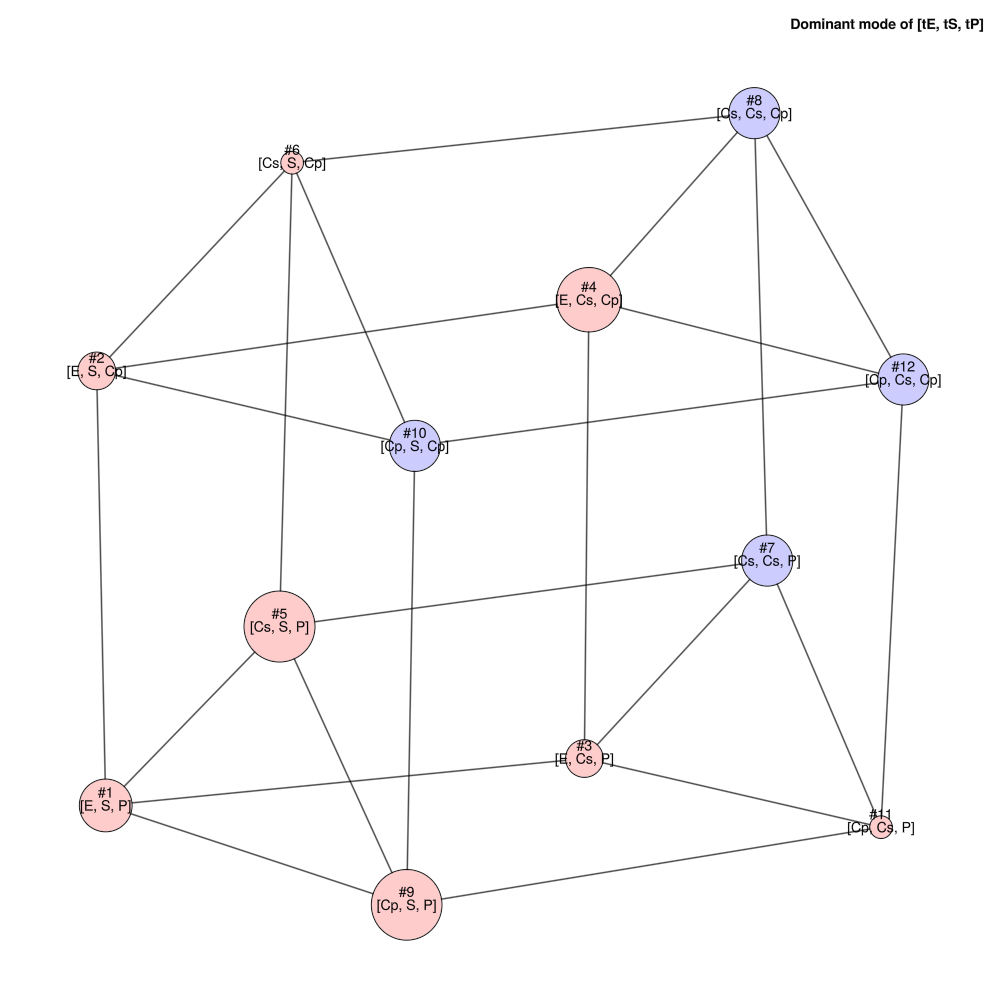

In [5]:
x_grh = get_neighbor_graph_x(model)

f,ax, p  = draw_graph(model, x_grh; edge_labels=["" for i in 1:BindingAndCatalysis.ne(x_grh)])
f

In [6]:
summary(model)

----------Binding Network Summary:-------------
Number of species (n): 5
Number of conserved quantities (d): 3
Number of reactions (r): 2
L matrix: [1 0 0 1 1; 0 1 0 1 0; 0 0 1 0 1]
N matrix: [1 1 0 -1 0; 1 0 1 0 -1]
Direction of binding reactions: forward
Catalysis involved: No
Regimes constructed: Yes
Number of regimes: 12
  - Invertible + Asymptotic: 8
  - Singular +  Asymptotic: 4
  - Invertible +  Non-Asymptotic: 0
  - Singular +  Non-Asymptotic: 0
-----------------------------------------------


In [7]:
get_nullities(model) |> maximum

1

1. So firstly this binding netowok have only asymptotic regimes, with maximum nullity 1.\\

1. Also, we find  regime **#7** and **#8** are neighbors \\

1. While regime **#8** and **#12** are x neighbors but not qK space neighbors

In [8]:
v1 = get_vertex(model, [:Cs,:Cs, :Cp]) #8 regime
v2 = get_vertex(model, [:Cp,:Cs, :Cp]) #12 regime
v3 = get_vertex(model, [:Cs,:Cs, :P]) #7 regime

BindingAndCatalysis.Vertex{Float64, Int8}(Bnc{Int8}([1 1 … -1 0; 1 0 … 0 -1], [1 0 … 1 1; 0 1 … 1 0; 0 0 … 0 1], 2, 5, 3, Symbolics.Num[E, S, P, Cs, Cp], Symbolics.Num[tE, tS, tP], Symbolics.Num[K₁, K₂], nothing, Vector{Int8}[[1, 2, 3], [1, 2, 5], [1, 4, 3], [1, 4, 5], [4, 2, 3], [4, 2, 5], [4, 4, 3], [4, 4, 5], [5, 2, 3], [5, 2, 5], [5, 4, 3], [5, 4, 5]], Dict{Vector{Int8}, Int64}([4, 2, 3] => 5, [4, 2, 5] => 6, [1, 2, 3] => 1, [5, 2, 3] => 9, [1, 2, 5] => 2, [4, 4, 3] => 7, [5, 2, 5] => 10, [4, 4, 5] => 8, [1, 4, 3] => 3, [5, 4, 3] => 11…), Bool[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], Int8[0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1], BindingAndCatalysis.VertexGraph{Int8}(Bnc{Int8}(#= circular reference @-2 =#), Graphs.SimpleGraphs.SimpleGraph{Int64}(24, [[2, 3, 5, 9], [1, 4, 6, 10], [1, 4, 7, 11], [2, 3, 8, 12], [1, 6, 7, 9], [2, 5, 8, 10], [3, 5, 8, 11], [4, 6, 7, 12], [1, 5, 10, 11], [2, 6, 9, 12], [3, 7, 9, 12], [4, 8, 10, 11]]), Vector{BindingAndCatalysis.VertexEdge{Int8}}[[BindingAndCataly

## Regime 8 and Regime 12 are x neighbor but not 

In [9]:
get_P(v1)

3×5 SparseArrays.SparseMatrixCSC{Int64, Int64} with 3 stored entries:
 ⋅  ⋅  ⋅  1  ⋅
 ⋅  ⋅  ⋅  1  ⋅
 ⋅  ⋅  ⋅  ⋅  1

In [10]:
get_P(v2)

3×5 SparseArrays.SparseMatrixCSC{Int64, Int64} with 3 stored entries:
 ⋅  ⋅  ⋅  ⋅  1
 ⋅  ⋅  ⋅  1  ⋅
 ⋅  ⋅  ⋅  ⋅  1

These two regimes are x-neighbor but not q,K neighbor, as we could show  their conditions:

In [11]:
show_condition(v1;log_space=false)

5-element Vector{Any}:
        tS ~ tE
 tE > K₂
 tE > K₁
    true
 tE > tP

In [12]:
show_condition(v2;log_space=false)

5-element Vector{Any}:
        tP ~ tE
 tE > K₂
 tE > K₁
    true
 tE > tS

The intersection will require $tS = tE = tP$

In [13]:
get_P(v3)

3×5 SparseArrays.SparseMatrixCSC{Int64, Int64} with 3 stored entries:
 ⋅  ⋅  ⋅  1  ⋅
 ⋅  ⋅  ⋅  1  ⋅
 ⋅  ⋅  1  ⋅  ⋅

In [14]:
show_condition(v3;log_space=false)

5-element Vector{Any}:
                  tS ~ tE
 (K₂*tE) > (K₁*tP)
           K₂ > K₁
           tE > K₁
              true

In [15]:
(p1,p2,p3) = get_polyhedron.([v1,v2,v3])

3-element Vector{CDDLib.Polyhedron{Float64}}:
 HyperPlane([1.0, -1.0, -0.0, -0.0, -0.0], 0.0) ∩ HalfSpace([-1.0, -0.0, -0.0, -0.0, 1.0], 0.0) ∩ HalfSpace([-1.0, -0.0, -0.0, 1.0, -0.0], 0.0) ∩ HalfSpace([-0.0, -0.0, -0.0, -0.0, -0.0], 1.0) ∩ HalfSpace([-1.0, -0.0, 1.0, -0.0, -0.0], 0.0)
 HyperPlane([1.0, -0.0, -1.0, -0.0, -0.0], 0.0) ∩ HalfSpace([-1.0, -0.0, -0.0, -0.0, 1.0], 0.0) ∩ HalfSpace([-1.0, -0.0, -0.0, 1.0, -0.0], 0.0) ∩ HalfSpace([-0.0, -0.0, -0.0, -0.0, -0.0], 1.0) ∩ HalfSpace([-1.0, 1.0, -0.0, -0.0, -0.0], 0.0)
 HyperPlane([1.0, -1.0, -0.0, -0.0, -0.0], 0.0) ∩ HalfSpace([-1.0, -0.0, 1.0, 1.0, -1.0], 0.0) ∩ HalfSpace([-0.0, -0.0, -0.0, 1.0, -1.0], 0.0) ∩ HalfSpace([-1.0, -0.0, -0.0, 1.0, -0.0], 0.0) ∩ HalfSpace([-0.0, -0.0, -0.0, -0.0, -0.0], 1.0)

In [16]:
dim(p1) == dim(p2) == dim(p3) == 4

true

In [17]:
p12 = p1 ∩ p2
p13 = p1 ∩ p3

Polyhedron CDDLib.Polyhedron{Float64}:
2-element iterator of HyperPlane{Float64, Vector{Float64}}:
 HyperPlane([1.0, -1.0, -0.0, -0.0, -0.0], 0.0)
 HyperPlane([1.0, -1.0, -0.0, -0.0, -0.0], 0.0),
8-element iterator of HalfSpace{Float64, Vector{Float64}}:
 HalfSpace([-1.0, -0.0, -0.0, -0.0, 1.0], 0.0)
 HalfSpace([-1.0, -0.0, -0.0, 1.0, -0.0], 0.0)
 HalfSpace([-0.0, -0.0, -0.0, -0.0, -0.0], 1.0)
 HalfSpace([-1.0, -0.0, 1.0, -0.0, -0.0], 0.0)
 HalfSpace([-1.0, -0.0, 1.0, 1.0, -1.0], 0.0)
 HalfSpace([-0.0, -0.0, -0.0, 1.0, -1.0], 0.0)
 HalfSpace([-1.0, -0.0, -0.0, 1.0, -0.0], 0.0)
 HalfSpace([-0.0, -0.0, -0.0, -0.0, -0.0], 1.0)

In [18]:
dim(p12) # the first two regimes are x-neighbor but not qK neighbor

3

In [19]:
dim(p13) # the first and third regimes have intersection.

4

In [20]:
p13

Polyhedron CDDLib.Polyhedron{Float64}:
1-element iterator of HyperPlane{Float64, Vector{Float64}}:
 HyperPlane([1.0, -1.0, -0.0, -0.0, -0.0], 0.0),
8-element iterator of HalfSpace{Float64, Vector{Float64}}:
 HalfSpace([-1.0, -0.0, -0.0, -0.0, 1.0], 0.0)
 HalfSpace([-1.0, -0.0, -0.0, 1.0, -0.0], 0.0)
 HalfSpace([-0.0, -0.0, -0.0, -0.0, -0.0], 1.0)
 HalfSpace([-1.0, -0.0, 1.0, -0.0, -0.0], 0.0)
 HalfSpace([-1.0, -0.0, 1.0, 1.0, -1.0], 0.0)
 HalfSpace([-0.0, -0.0, -0.0, 1.0, -1.0], 0.0)
 HalfSpace([-1.0, -0.0, -0.0, 1.0, -0.0], 0.0)
 HalfSpace([-0.0, -0.0, -0.0, -0.0, -0.0], 1.0)

In [21]:
locate_sym_qK(model,:tE)

1

In [22]:
p12_lowerdim = eliminate(p12, BitSet(1))
p13_lowerdim = eliminate(p13, BitSet(1))
p1_lowerdim = eliminate(p1, BitSet(1))
p3_lowerdim = eliminate(p3, BitSet(1))

Polyhedron CDDLib.Polyhedron{Float64}:
4-element iterator of HalfSpace{Float64, Vector{Float64}}:
 HalfSpace([-1.0, 1.0, 1.0, -1.0], 0.0)
 HalfSpace([-0.0, -0.0, 1.0, -1.0], 0.0)
 HalfSpace([-1.0, -0.0, 1.0, -0.0], 0.0)
 HalfSpace([-0.0, -0.0, -0.0, -0.0], 1.0)

In [23]:
dim(p12_lowerdim)

3

In [24]:
dim(p13_lowerdim) == dim(p1_lowerdim) == dim(p3_lowerdim) == dim(p1) == dim(p3) == dim(p13)

true

In [25]:
Vol = calc_volume([p1_lowerdim,p3_lowerdim, p13_lowerdim])

[ Info: Number of polyhedra to calc volume: 3
[ Info: All regimes converged after 1900000 samples.


3-element Vector{BindingAndCatalysis.Volume}:
 Volume(Mean=2.498e-01, STD=1.200e-03, RelError=0.48%)
 Volume(Mean=2.020e-01, STD=9.406e-04, RelError=0.47%)
 Volume(Mean=7.898e-02, STD=3.835e-04, RelError=0.49%)

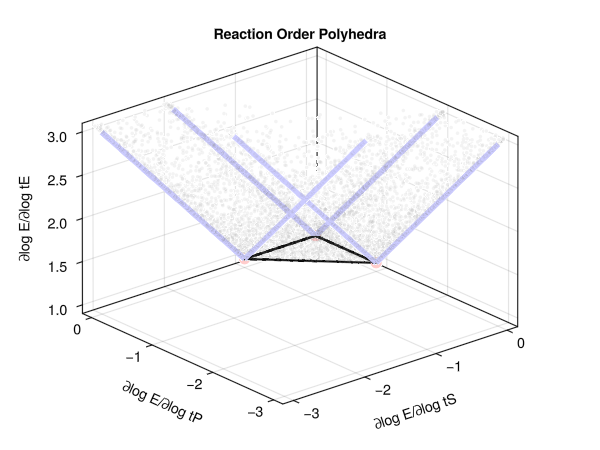

In [26]:
f,ax = draw_ROP(model, [(:E, :tS), (:E, :tP), (:E, :tE)]; emphasize_regimes=[],npoints=100000)
f

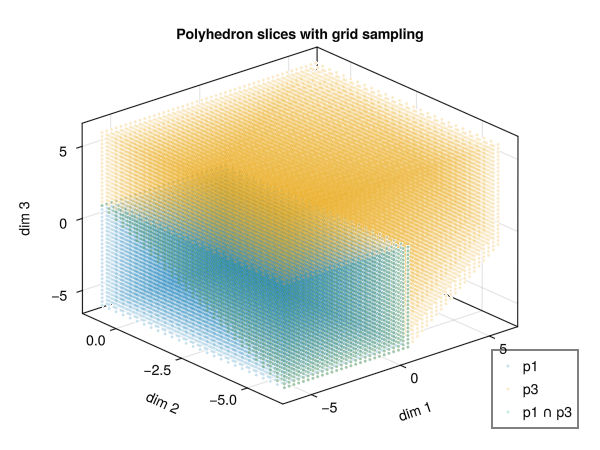

In [44]:
fig, ax, sliced, sampled, used_bounds = plot_polyhedron_slices(
    [p1_lowerdim, p3_lowerdim, p13_lowerdim];
    fixed_idx=[1],
    fixed_value=1.0,
    labels=["p1", "p3", "p1 ∩ p3"],
    bounds=((-6.0, 6.0), (-6.0, 6.0), (-6.0, 6.0)),   # 无界时建议手动给
    npoints=100000,
    markersize=4,
    alpha=0.22,
    title="Polyhedron slices with grid sampling",
)
fig

In [45]:
display(fig)

GLMakie.Screen(...)